# Fase 3: Transfer Learning (Optimizado para GTX 1050 Ti)

En esta fase utilizamos un modelo preentrenado para resolver el problema de clasificación de *landmarks*, aplicando la técnica de Transfer Learning (congelando el extractor de características y entrenando un nuevo clasificador).

## 1. Justificación del Modelo Preentrenado

Se ha elegido la arquitectura **ResNet18**. 
* **Justificación técnica:** Las redes residuales (ResNet) solucionan el problema del desvanecimiento del gradiente en redes profundas mediante conexiones *skip*. ResNet18 ofrece un excelente equilibrio entre capacidad de representación (suficiente para extraer patrones complejos de arquitectura y paisajes) y eficiencia computacional.
* **Justificación de hardware:** Dado el límite de 4GB de VRAM en la GPU local (GTX 1050 Ti), ResNet18 permite utilizar un tamaño de lote (*batch size*) razonable sin provocar desbordamientos de memoria (OOM), garantizando un entrenamiento estable y rápido.

In [1]:
import os
import sys
from pathlib import Path

# Utilizamos exactamente las mismas rutas seguras de la Fase 2
PROJECT_DIR = Path(r"D:\DESCARGAS\PYPAUL\proyecto_1\landmark-classifier")
DATA_ROOT = Path(r"D:\DESCARGAS\PYPAUL\proyecto_1\Proyecto 1 Data set\landmark_images")

os.chdir(PROJECT_DIR)

print(f"Directorio del proyecto: {PROJECT_DIR}")
print(f"Ruta del dataset: {DATA_ROOT}")

assert DATA_ROOT.exists(), f"No se encontró el dataset en {DATA_ROOT}"

Directorio del proyecto: D:\DESCARGAS\PYPAUL\proyecto_1\landmark-classifier
Ruta del dataset: D:\DESCARGAS\PYPAUL\proyecto_1\Proyecto 1 Data set\landmark_images


## 2. Entrenamiento (Transfer Learning)
Procedemos a entrenar la nueva capa clasificadora final (`fc`). Como la red base ya sabe identificar bordes, texturas y formas, no necesitamos 35 épocas. Con **20 épocas** suele ser más que suficiente para que el modelo converja.

In [2]:
import sys
import os
import subprocess

# 1. Hiperparámetros adaptados a tu GTX 1050 Ti
BACKBONE = 'resnet18'
EPOCHS = 20 
BATCH_SIZE = 32  # Mantenemos 16 para evitar el "CUDA error: out of memory"
LR = "1e-3"
OUT_DIR = "outputs/transfer_run_gpu"
MODEL_PATH = "models/transfer_best_gpu.pt"

# 2. El comando convertido a formato lista (ESTO REEMPLAZA AL "!")
comando = [
    sys.executable, "-u", "-m", "src.train",
    "--data-root", str(DATA_ROOT),
    "--model-type", "transfer",
    "--backbone", BACKBONE,
    "--epochs", str(EPOCHS),
    "--batch-size", str(BATCH_SIZE),
    "--lr", LR,
    "--weight-decay", "1e-4",
    "--use-cosine-scheduler",
    "--num-workers", "0",  # 0 garantiza que no haya cuellos de botella silenciosos en Windows
    "--checkpoint-every", "5",
    "--output-dir", OUT_DIR,
    "--export-path", MODEL_PATH
]

print(f"🚀 Iniciando Transfer Learning ({BACKBONE}) con Batch Size {BATCH_SIZE}...")
print("="*60)

# 3. El Túnel de Comunicación
proceso = subprocess.Popen(comando, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)

for linea in proceso.stdout:
    print(linea, end="")

proceso.wait()

if proceso.returncode == 0:
    print("\n" + "="*60 + "\n✅ Transfer Learning completado exitosamente.")
else:
    print("\n" + "="*60 + f"\n❌ Error en el entrenamiento. Código: {proceso.returncode}")

🚀 Iniciando Transfer Learning (resnet18) con Batch Size 32...
device=cuda
cudnn_benchmark=enabled
d:\DESCARGAS\PYPAUL\proyecto_1\landmark-classifier\src\train.py:240: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if device.type == "cuda" else None
amp=True
classes=50, train_batches=125
epoch=001 train_loss=3.1905 train_acc=0.2554 val_loss=2.2820 val_acc=0.4745
epoch=002 train_loss=2.0980 train_acc=0.5249 val_loss=1.7156 val_acc=0.5996
epoch=003 train_loss=1.7297 train_acc=0.5984 val_loss=1.5171 val_acc=0.6346
epoch=004 train_loss=1.5284 train_acc=0.6265 val_loss=1.4203 val_acc=0.6486
epoch=005 train_loss=1.3971 train_acc=0.6662 val_loss=1.3645 val_acc=0.6647
checkpoint_epoch=outputs\transfer_run_gpu\checkpoints\epoch_005.pth
epoch=006 train_loss=1.3108 train_acc=0.6755 val_loss=1.3277 val_acc=0.6597
epoch=007 train_loss=1.2576 train_acc=0.6805 val_loss=

## 3. Evaluación Individual (Transfer Learning)
Verificamos que el modelo cumpla con el umbral de la rúbrica ($\ge 70\%$).

--- RESUMEN TRANSFER LEARNING ---
Test Accuracy: 72.72%
Mejor Época: 19


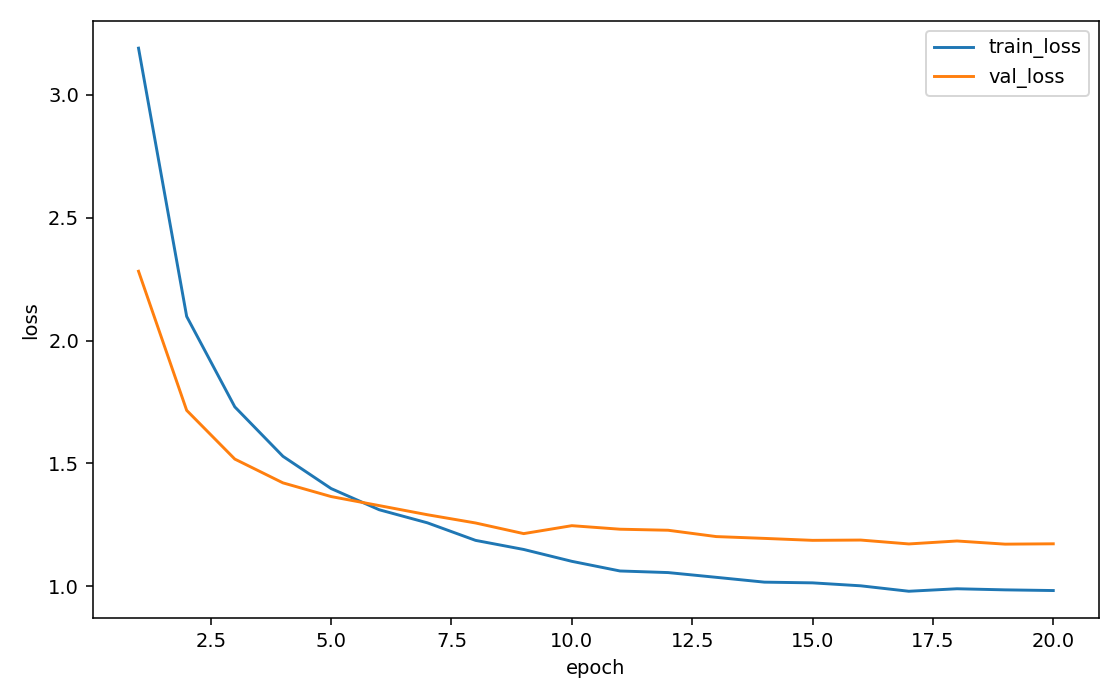

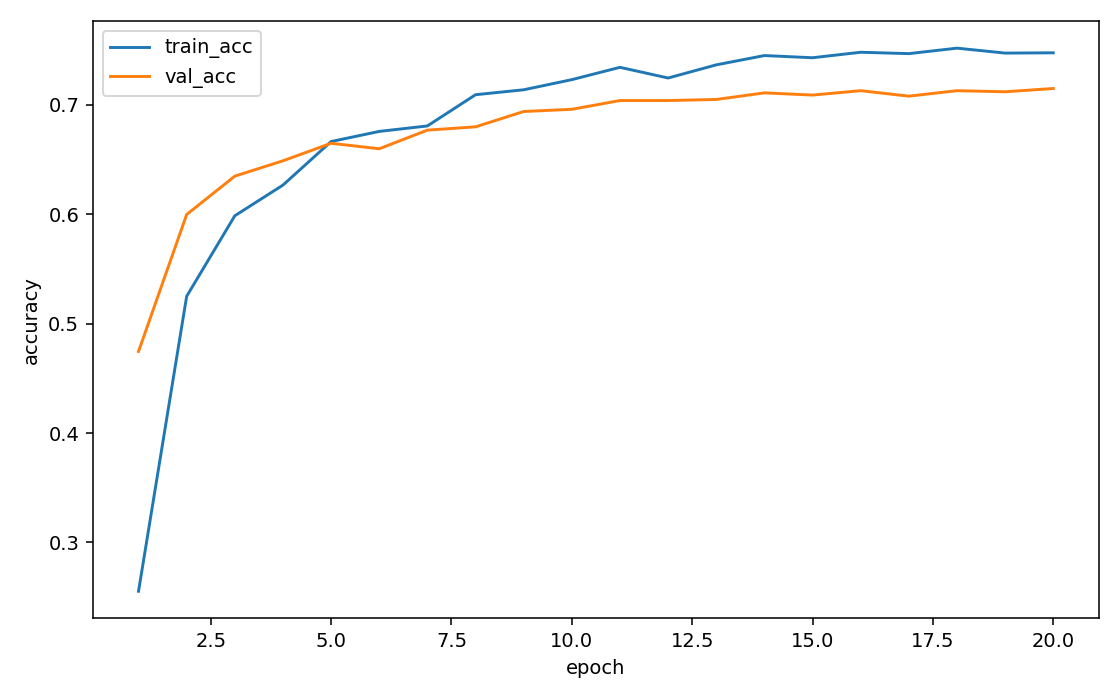

In [3]:
import json
import pandas as pd
from IPython.display import display, Image

# Cargar métricas
with open(f"{OUT_DIR}/summary.json", "r") as f:
    transfer_summary = json.load(f)

test_acc = transfer_summary['test_acc']
print("--- RESUMEN TRANSFER LEARNING ---")
print(f"Test Accuracy: {test_acc:.2%}")
print(f"Mejor Época: {transfer_summary.get('best_epoch', 'N/A')}")

# Verificación de rúbrica
assert test_acc >= 0.70, 'El modelo no alcanzó el 70% mínimo.'
if test_acc >= 0.75:
    print("🌟 ¡Excelente! Has conseguido el punto de bonificación (>= 75%).")

# Mostrar curvas
try:
    display(Image(filename=f'{OUT_DIR}/loss_curve.png', width=600))
    display(Image(filename=f'{OUT_DIR}/accuracy_curve.png', width=600))
except FileNotFoundError:
    print("Gráficos no encontrados.")

## 4. Comparación: Transfer Learning vs. Scratch
La rúbrica exige comparar los resultados de la Fase 3 con los obtenidos en la Fase 2. Usaremos el script de comparación apuntando a los resultados generados anteriormente.

             scratch | acc=53.36% | loss=2.2811 | backbone=None
            transfer | acc=72.72% | loss=1.0562 | backbone=resnet18

Comparación guardada en: outputs\comparison
# Comparación de Modelos

| Modelo | Tipo | Backbone | Epochs | Test Accuracy | Test Loss |
|---|---|---|---:|---:|---:|
| scratch | scratch | None | 35 | 53.36% | 2.2811 |
| transfer | transfer | resnet18 | 20 | 72.72% | 1.0562 |

- Scratch cumple umbral (40%): sí
- Transfer cumple umbral (70%): sí
- Transfer supera a scratch: sí


,model,model_type,backbone,epochs,test_acc,test_acc_pct,test_loss
0,scratch,scratch,NaN,35,0.5336,53.36,2.281069
1,transfer,transfer,resnet18,20,0.7272,72.72,1.056219


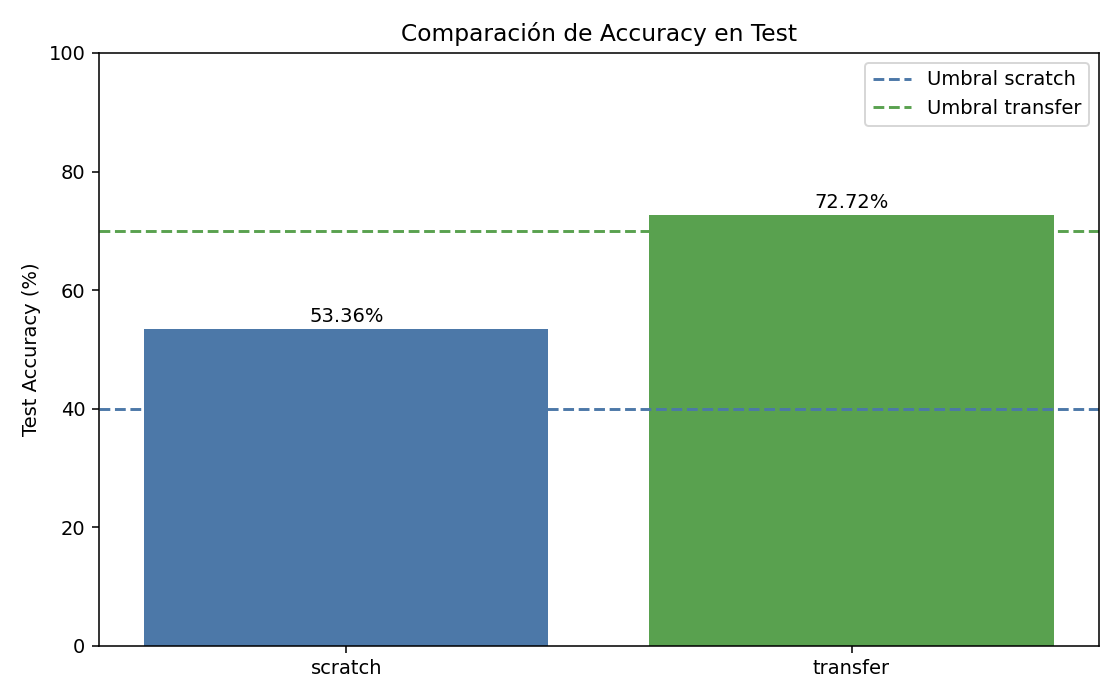

In [4]:
# Apuntamos el comparador al directorio donde guardamos los resultados de la Fase 2
SCRATCH_SUMMARY = "outputs/final_run_gpu/summary.json"
TRANSFER_SUMMARY = f"{OUT_DIR}/summary.json"
COMPARE_DIR = "outputs/comparison"

!{sys.executable} -m src.compare_models \
    --scratch-summary "{SCRATCH_SUMMARY}" \
    --transfer-summary "{TRANSFER_SUMMARY}" \
    --scratch-threshold 0.40 \
    --transfer-threshold 0.70 \
    --out-dir "{COMPARE_DIR}"

# Mostramos los resultados de la comparación
print(Path(f'{COMPARE_DIR}/model_comparison.md').read_text(encoding='utf-8'))
display(pd.read_csv(f'{COMPARE_DIR}/model_comparison.csv'))

try:
    display(Image(filename=f'{COMPARE_DIR}/test_accuracy_comparison.png', width=600))
except FileNotFoundError:
    print("Gráfico de comparación no generado.")